# LDDMM: parallel transport

Imagine we are given three meshes A, B, C.

In this notebook we will:

* register A to B (fixed), and C to B (fixed)

* parallel transport BC along BA

In [1]:
import shutil
import string

import numpy as np
import pyvista as pv

import polpo.utils as putils
from polpo.mesh.deformetrica import LddmmMetric, Point
from polpo.mesh.generation.blob import create_blob
from polpo.plot.pyvista import RegisteredMeshesGifPlotter
from polpo.preprocessing.mesh.registration import RigidAlignment

[KeOps] Warning : CUDA was detected, but driver API could not be initialized. Switching to CPU only.


In [2]:
RECOMPUTE = False

# NB: fix seed before setting it to False
np.random.seed(42)

STATIC_VIZ = True

if STATIC_VIZ:
    pv.set_jupyter_backend("static")

In [3]:
OUTPUTS_DIR = putils.get_results_path() / "transport_abc_blob_example"

if OUTPUTS_DIR.exists() and RECOMPUTE:
    shutil.rmtree(OUTPUTS_DIR)

## Generate meshes

In [4]:
n_meshes = 3
bump_amp = 0.2

raw_meshes = [
    create_blob(resolution=10, bump_amp=bump_amp, n_bumps=5, smoothing_iter=10)
    for _ in range(n_meshes)
]

raw_meshes[0].points.shape

(82, 3)

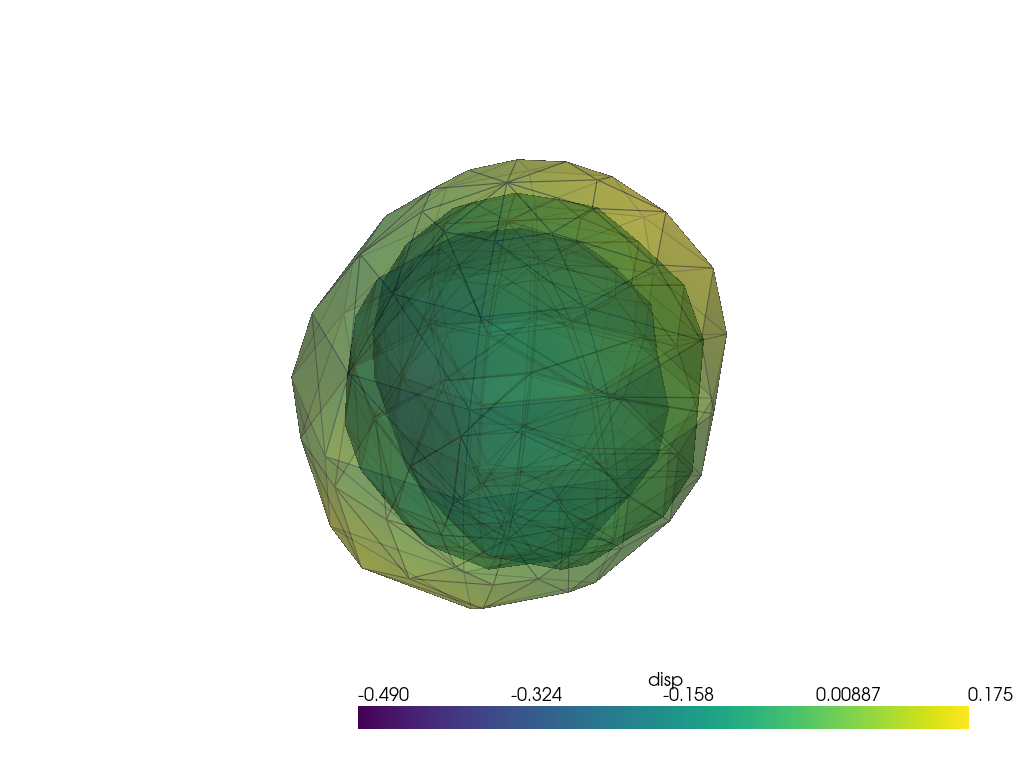

In [5]:
pl = pv.Plotter(border=False)

for mesh in raw_meshes:
    pl.add_mesh(mesh, show_edges=True, opacity=0.5)

pl.show()

In [6]:
prep_pipe = RigidAlignment(known_correspondences=True)

meshes = prep_pipe(raw_meshes)

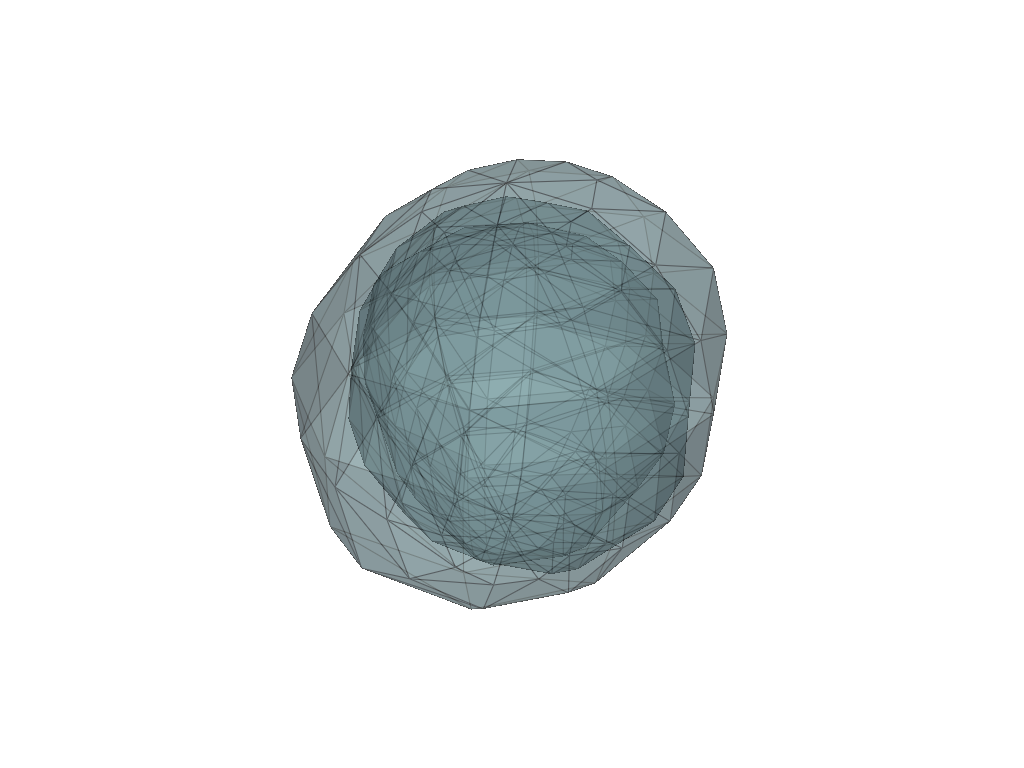

In [7]:
pl = pv.Plotter(border=False)

for mesh in meshes:
    pl.add_mesh(mesh, show_edges=True, opacity=0.5)

pl.show()

## Registrations

In [8]:
kernel_width = 2 * bump_amp
registration_kwargs = dict(
    kernel_width=kernel_width,
    regularisation=1.0,
    max_iter=2000,
    freeze_control_points=False,
    metric="varifold",
    tol=1e-16,
    attachment_kernel_width=bump_amp,
)

metric = LddmmMetric(OUTPUTS_DIR, use_pole_ladder=True, **registration_kwargs)

In [9]:
point_a, point_b, point_c = [
    Point(id_=string.ascii_uppercase[index], pv_surface=mesh, dirname=metric.meshes_dir)
    for index, mesh in enumerate(meshes)
]

Closely following [LDDMM: how to register a mesh to a template?](./deformetrica_register_mesh_template.ipynb), we register A to B and C to B.

In [10]:
vec_ba = metric.log(point_a, point_b)
vec_bc = metric.log(point_c, point_b)

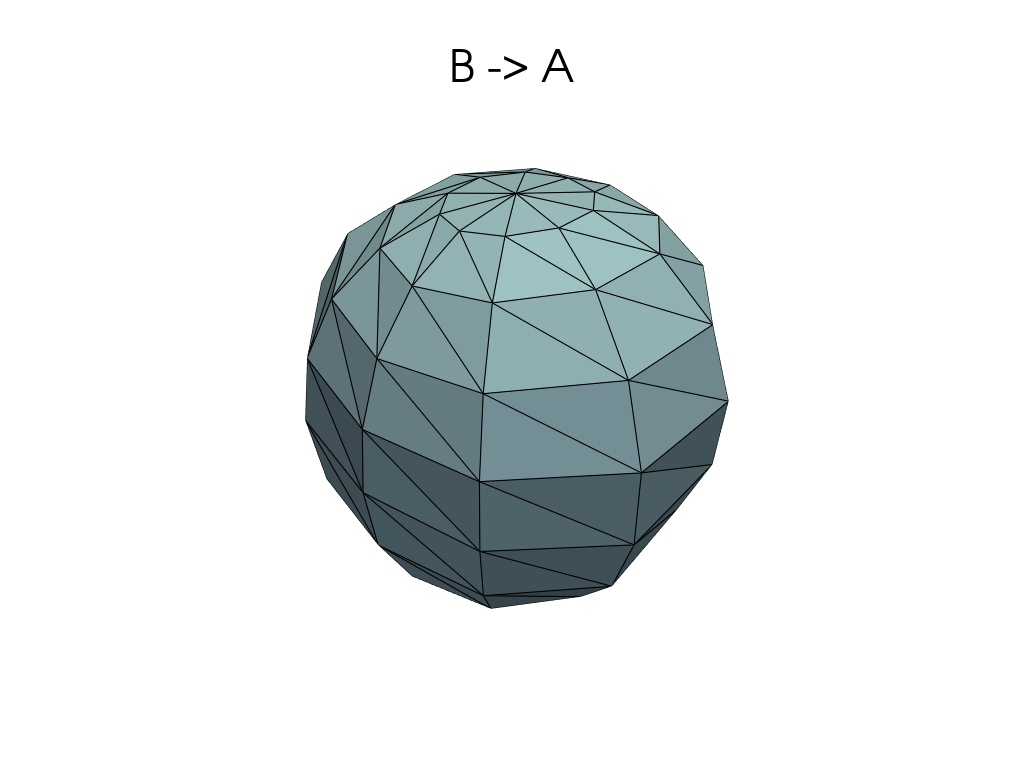

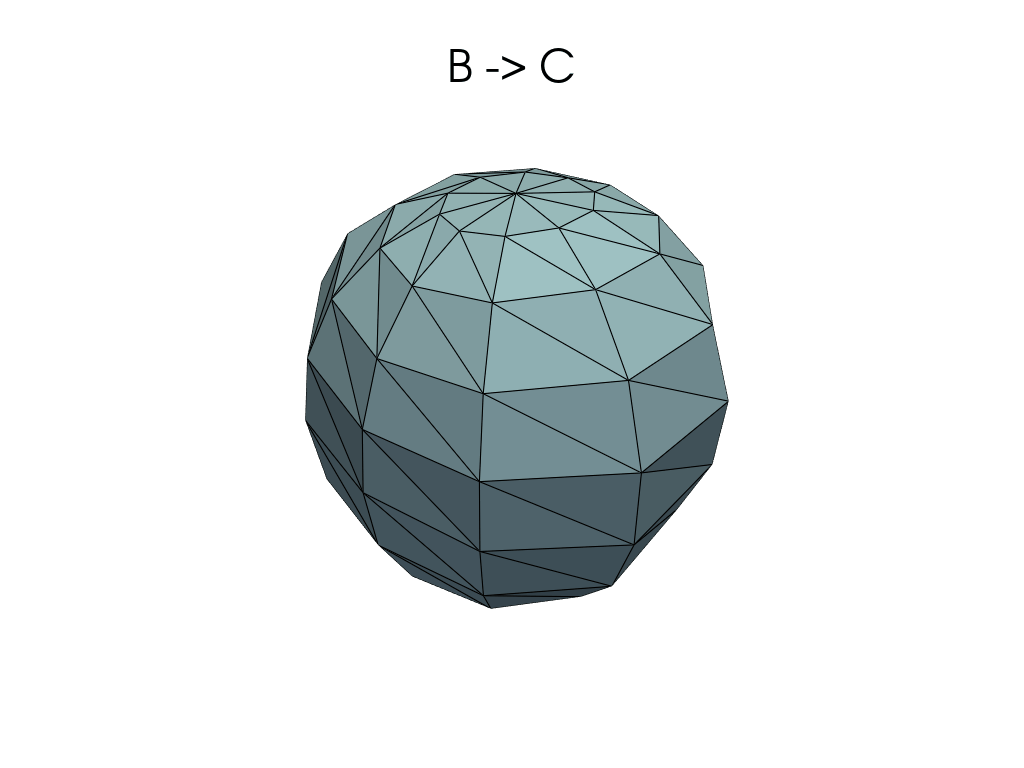

In [11]:
for vec in [vec_ba, vec_bc]:
    pl = RegisteredMeshesGifPlotter()
    pl.add_title(f"{vec.base_point.id} -> {vec.point.id}")

    pl.add_meshes(vec.flow())
    pl.close()

    pl.show()

## Parallel transport (pole ladder)

In [12]:
# NB: way slower?
trans_vec_bc_pole = metric.parallel_transport(vec_bc, point_b, direction=vec_ba)

This is how the deformation B->C looks from A.

In [13]:
trans_point_c_pole = metric.exp(trans_vec_bc_pole, point_a)

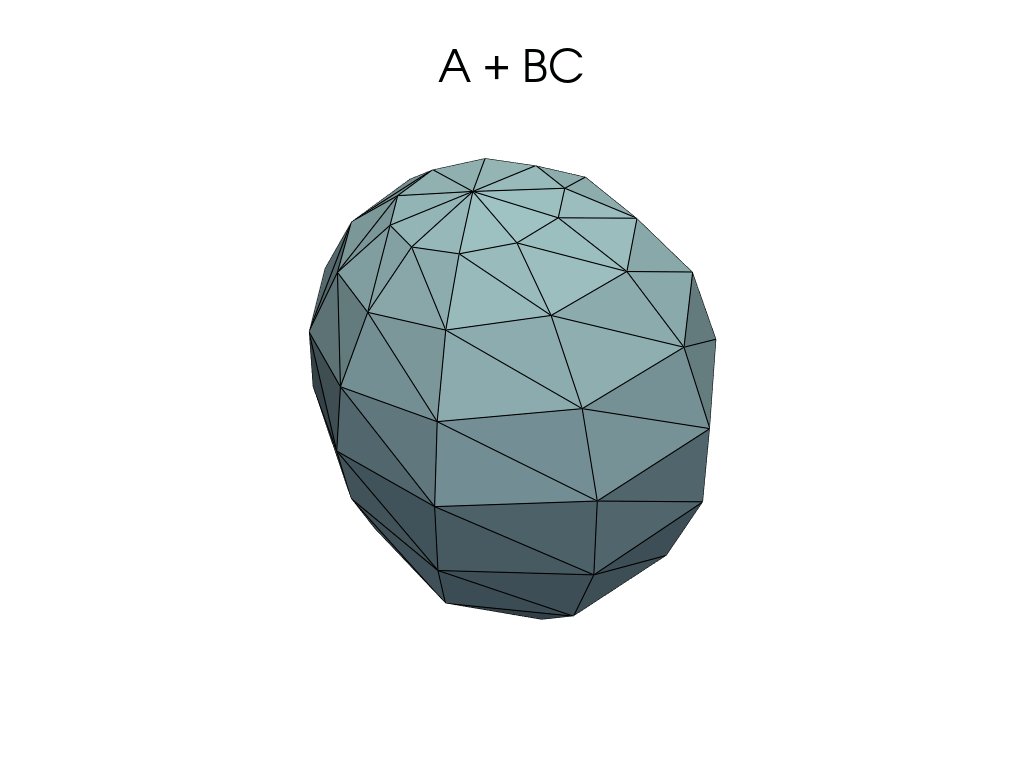

In [22]:
pl = RegisteredMeshesGifPlotter()

pl.add_title("A + BC")
pl.add_meshes(trans_point_c_pole.flow())
pl.close()

pl.show()

## Parallel transport (fanning)

In [15]:
metric.use_pole_ladder = False

In [16]:
trans_vec_bc_fan = metric.parallel_transport(vec_bc, point_b, direction=vec_ba)

This is how the deformation B->C looks from A.

In [17]:
trans_point_c_fan = metric.exp(trans_vec_bc_fan, point_a)

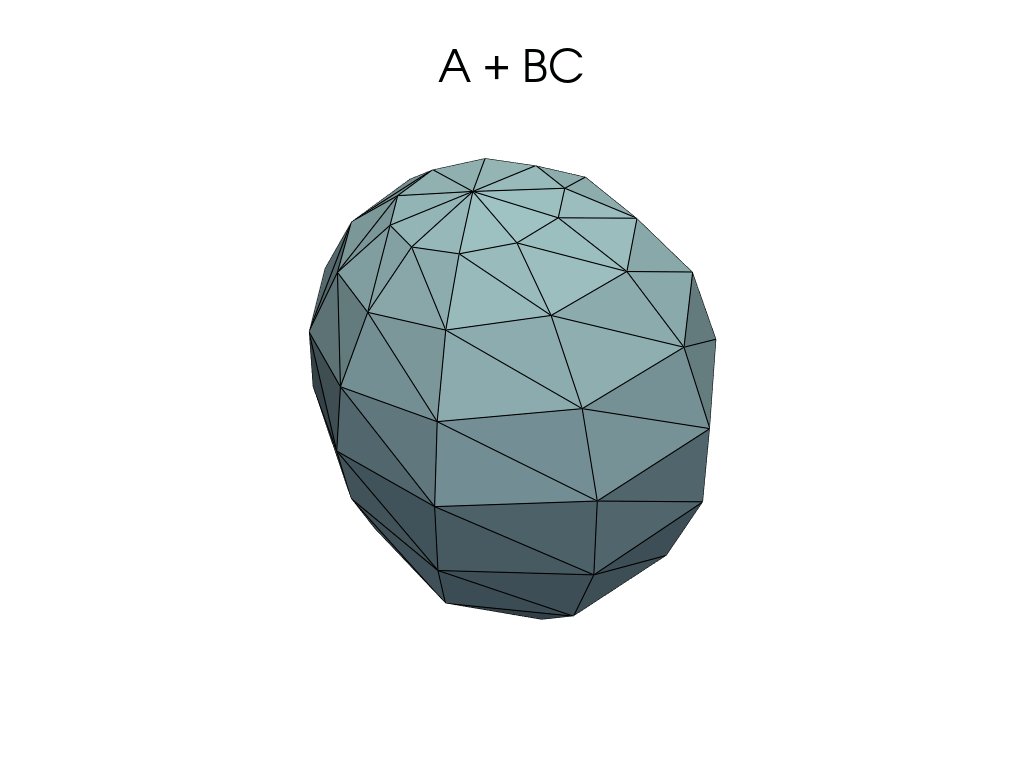

In [23]:
pl = RegisteredMeshesGifPlotter()

pl.add_title("A + BC")
pl.add_meshes(trans_point_c_fan.flow())

pl.close()

pl.show()

## Some comparisons

Extra information is computed with the fanning scheme:
* an approximation of the end point of direction
* a shooted mesh from that approximation using parallel transport

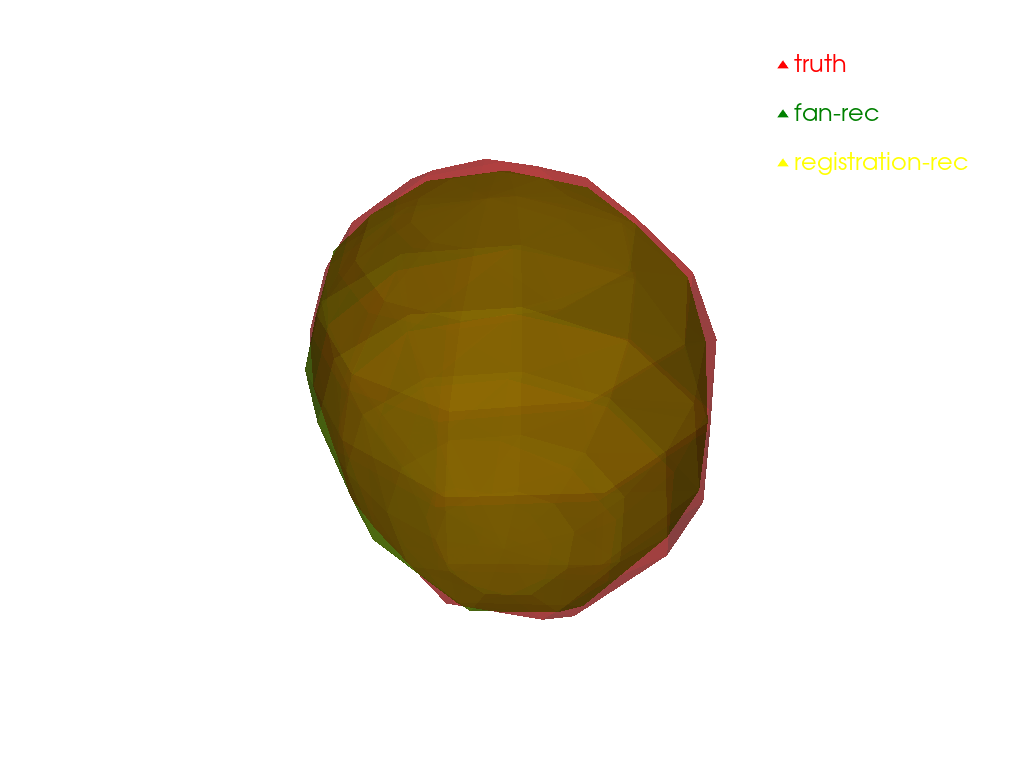

In [19]:
pl = pv.Plotter()

pl.add_mesh(
    point_a.as_pv(),
    color="red",
    opacity=0.5,
    label="truth",
)
pl.add_mesh(
    trans_vec_bc_fan.reconstructed().as_pv(),
    color="green",
    opacity=0.5,
    label="fan-rec",
)
pl.add_mesh(
    vec_ba.reconstructed().as_pv(),
    color="yellow",
    opacity=0.5,
    label="registration-rec",
)


pl.add_legend()

pl.show()

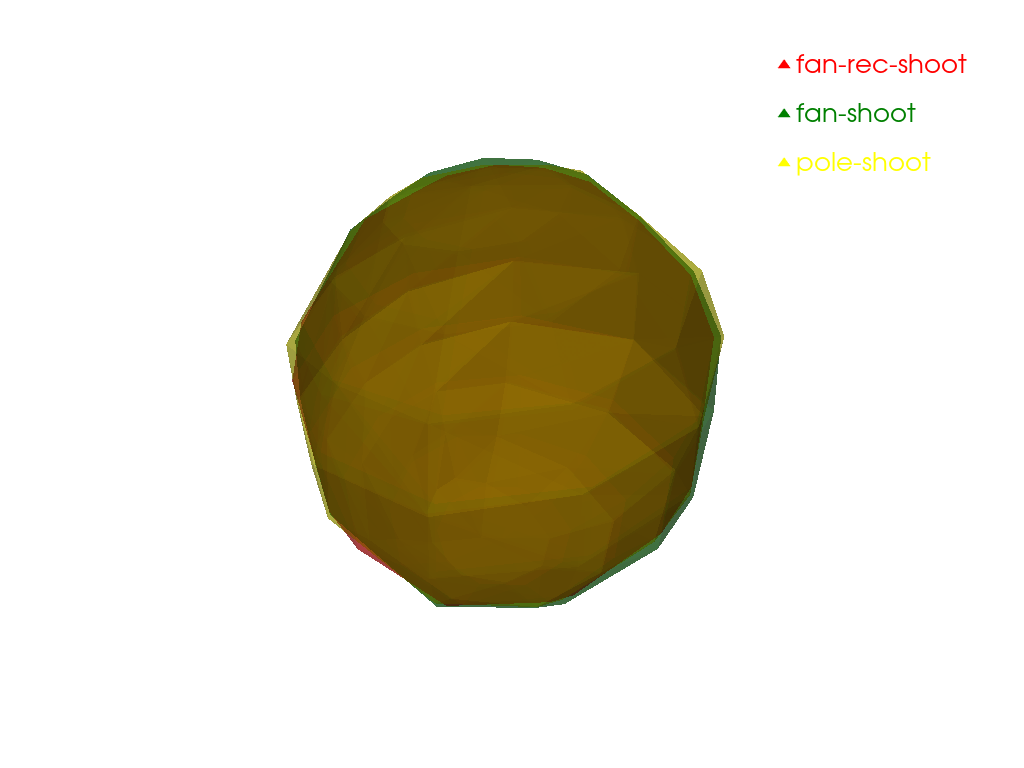

In [20]:
pl = pv.Plotter()

pl.add_mesh(
    trans_vec_bc_fan.reconstructed_shooted().as_pv(),
    color="red",
    opacity=0.5,
    label="fan-rec-shoot",
)
pl.add_mesh(
    trans_point_c_fan.as_pv(),
    color="green",
    opacity=0.5,
    label="fan-shoot",
)
pl.add_mesh(
    trans_point_c_pole.as_pv(),
    color="yellow",
    opacity=0.5,
    label="pole-shoot",
)

pl.add_legend()

pl.show()